# DRCNET
## output all volumes

In [1]:
import logging

# this ensures log messages go to the console and sets the minimum level to INFO
logging.basicConfig(level=logging.INFO)

# if you want to see debug messages, you can change it to:
# logging.basicConfig(level=logging.DEBUG)
# you can get a logger, often named after your module or just a general one
logger = logging.getLogger(__name__)

# now, use the logger to send messages at different levels
logger.debug("this is a debug message - you won't see it with INFO level config")
logger.info("this is an info message - you'll see this!")
logger.warning("this is a warning message - pay attention!")
logger.error("uh oh, an error occurred!")
logger.critical("system is failing!")

INFO:__main__:this is an info message - you'll see this!
ERROR:__main__:uh oh, an error occurred!
CRITICAL:__main__:system is failing!


In [2]:
from __future__ import annotations

import argparse
import gc
import logging
import os
import sys

import numpy as np
import torch
from drcnet_hybrid_2.data import TrainingDataSet
from drcnet_hybrid_2.fit import fit_model
from drcnet_hybrid_2.model import DenoiserNet
from drcnet_hybrid_2.reconstruction import (
    reconstruct_dwis,
    reconstruct_full_dwi_chunked,
    reconstruct_full_dwi_static_base,
    reconstruct_dwis_index_volume,
)
from drcnet_hybrid.run import fit_progressive
from torch.utils.data import DataLoader, Subset
from utils import setup_logging
from utils.checkpoint import load_checkpoint
from utils.data import (
    StanfordDataLoader,
    compute_brain_mask,
    rescale_reconstruction_to_01,
)
from utils.metrics import (
    compute_metrics,
    fully_compare_volumes,
    save_metrics,
    visualize_single_volume,
)
from utils.multi_gpu import create_multi_gpu_config_from_dict, setup_multi_gpu
from utils.utils import load_config, noise_path_segment

import wandb


def _build_checkpoint_dir(settings, train_num_volumes: int) -> str:
    noise_segment = noise_path_segment(
        getattr(settings.data, "noise_type", "rician"),
        getattr(settings.data, "noise_sigma", 0.1),
    )
    bvalue_segment = f"b{getattr(settings.data, 'bvalue', 2500)}"
    return os.path.join(
        settings.train.checkpoint_dir,
        bvalue_segment,
        f"num_volumes_{train_num_volumes}",
        noise_segment,
        f"learning_rate_{settings.train.learning_rate}",
    )


def _prepare_stanford_arrays(settings, train_num_volumes: int):
    d = settings.data
    data_loader = StanfordDataLoader(
        bvalue=d.bvalue,
        noise_sigma=d.noise_sigma,
    )
    original_data, noisy_data = data_loader.load_data()
    if original_data is None:
        original_data = noisy_data
        logging.info(
            "StanfordDataLoader returned original_data=None; using noisy_data as reference"
        )

    tx, ty, tz = d.take_x, d.take_y, d.take_z
    cropped_noisy = noisy_data[:tx, :ty, :tz, :].copy()
    cropped_orig = original_data[:tx, :ty, :tz, :].copy()

    n_b0 = int(d.num_b0s)
    dwi_noisy = cropped_noisy[..., n_b0:]
    dwi_orig = cropped_orig[..., n_b0:]
    n_dwi = dwi_noisy.shape[-1]
    logging.info(
        f"After spatial crop and b0 skip: DWI shape (X,Y,Z,V)={dwi_noisy.shape}, "
        f"V={n_dwi} diffusion volumes (excluding {n_b0} b0s)"
    )

    if train_num_volumes > n_dwi:
        raise ValueError(
            f"train_num_volumes={train_num_volumes} exceeds available DWI volumes ({n_dwi})"
        )

    train_noisy = dwi_noisy[..., :train_num_volumes]
    train_orig = dwi_orig[..., :train_num_volumes]

    return train_noisy, train_orig, dwi_noisy, dwi_orig


script_dir = "/teamspace/studios/this_studio/TechJourney/DWMRI/src/drcnet_hybrid_2"
config_path = os.path.join(script_dir, "config.yaml")
settings = load_config(config_path).dbrain

train_num_volumes = int(getattr(settings.data, "train_num_volumes", settings.data.num_volumes))
reconstruct_full = bool(getattr(settings.data, "reconstruct_full_dwi", True))

settings.data.num_volumes = train_num_volumes
settings.model.in_channel = train_num_volumes

d = settings.data
spatial_full = (d.take_x, d.take_y, d.take_z)
rec_dev = settings.reconstruct.device

INFO:numexpr.utils:NumExpr defaulting to 4 threads.
INFO:root:Loading configuration from: /teamspace/studios/this_studio/TechJourney/DWMRI/src/drcnet_hybrid_2/config.yaml
INFO:root:Configuration file loaded successfully
INFO:root:Configuration converted to Munch object


In [3]:
spatial_full

(128, 128, 96)

In [4]:
from utils.data import DBrainDataLoader

data_loader = DBrainDataLoader(
    nii_path=settings.data.nii_path,
    bvecs_path=settings.data.bvecs_path,
    bvalue=settings.data.bvalue,
    noise_sigma=settings.data.noise_sigma,
    noise_type=getattr(settings.data, "noise_type", "rician"),
    n_coils=getattr(settings.data, "noise_n_coils", 1),
)
original_data, noisy_data = data_loader.load_data()

INFO:root:DBrainDataLoader initialized - nii_path: /teamspace/s3_folders/dwmri-dataset/D_BRAIN_b2500_6_60_14_HCP_nless.nii, bvecs_path: /teamspace/s3_folders/dwmri-dataset/D_BRAIN_b2500_6_60_HCP_b_matrix.txt, bvalue: 2500, noise_sigma: 0.1, noise_type: rician, n_coils: 1
INFO:root:Loading data from /teamspace/s3_folders/dwmri-dataset/D_BRAIN_b2500_6_60_14_HCP_nless.nii
pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
INFO:nibabel.global:pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
INFO:root:Raw data loaded - shape: (128, 128, 97, 66), dtype: float64
INFO:root:Raw data stats - min: 0.0000, max: 7462.0000, mean: 159.3769
INFO:root:Normalizing spatial dimensions...
INFO:root:Normalizing spatial dimensions for data of shape (128, 128, 97, 66)
INFO:root:Spatial normalization completed - output shape: (128, 128, 97, 66)
INFO:root:Normalized data stats - min: 0.0000, max: 1.0000, mean: 0.1140
INFO:root:Adding rician noise with sigma=0.1 to data of shape (128,

In [5]:
rec_model = DenoiserNet(
    input_channels=train_num_volumes,
    output_channels=settings.model.out_channel,
    groups=settings.model.groups,
    dense_convs=settings.model.dense_convs,
    residual=settings.model.residual,
    base_filters=settings.model.base_filters,
    output_shape=(
        settings.model.out_channel,
        spatial_full[0],
        spatial_full[1],
        spatial_full[2],
    ),
    device=settings.train.device,
    output_activation=getattr(settings.model, "output_activation", "prelu"),
)

INFO:root:Initializing DenoiserNet: input_channels=10, output_channels=10, groups=2, dense_convs=4, residual=True, base_filters=32, output_activation=prelu
INFO:root:Initializing GatedBlock: x_channels=32, h_channels=32, dense_convs=4, groups=2
INFO:root:Initializing DenoisingBlock: in_channels=64, inner_channels=32, out_channels=32, inner_convolutions=4, residual=False
INFO:root:Initializing FactorizedBlock: in_channels=96, out_channels=32, groups=2
INFO:root:Initializing FactorizedBlock: in_channels=128, out_channels=32, groups=2
INFO:root:Initializing FactorizedBlock: in_channels=160, out_channels=32, groups=2
INFO:root:Initializing FactorizedBlock: in_channels=192, out_channels=32, groups=2
INFO:root:DenoiserNet model created - Total parameters: 139,604, Trainable parameters: 139,604


In [6]:
checkpoint_dir = "/teamspace/studios/this_studio/drcnet_hybrid_2/checkpoints/dbrain/b2500/num_volumes_10/noise_rician_sigma_0.1/learning_rate_0.0003/"
best_ckpt = os.path.join(checkpoint_dir, "best_loss_checkpoint.pth")

rec_model, _, _, _, _, _ = load_checkpoint(
    model=rec_model,
    optimizer=None,
    filename=best_ckpt,
    device=rec_dev,
    strict=False,
)

INFO:root:Attempting to load checkpoint from: /teamspace/studios/this_studio/drcnet_hybrid_2/checkpoints/dbrain/b2500/num_volumes_10/noise_rician_sigma_0.1/learning_rate_0.0003/best_loss_checkpoint.pth
/teamspace/studios/this_studio/TechJourney/DWMRI/src/utils/checkpoint.py:45: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for a

In [7]:
take_volumes = settings.data.num_b0s + settings.data.num_volumes
noisy_data = noisy_data[
    : settings.data.take_x,
    : settings.data.take_y,
    : settings.data.take_z,
    settings.data.num_b0s :,
]
original_data = original_data[
    : settings.data.take_x,
    : settings.data.take_y,
    : settings.data.take_z,
    settings.data.num_b0s :,
]

In [8]:
noisy_data.shape

(128, 128, 96, 60)

In [9]:
reconstructed = reconstruct_full_dwi_chunked(
    model=rec_model,
    noisy_xyzv=noisy_data[..., :20],
    train_num_volumes=train_num_volumes,
    device=rec_dev,
    mask_p=settings.reconstruct.mask_p,
    n_preds=100,  # settings.reconstruct.n_preds,
)

INFO:root:Starting DWI reconstruction on device: cuda
INFO:root:Input data shape: torch.Size([10, 128, 128, 96])
INFO:root:Using hybrid MD-S2S approach with mask_p=0.3, n_preds=100
INFO:root:Reconstruction completed. Output shape: (10, 128, 128, 96)
INFO:root:Output stats - Min: 0.0467, Max: 1.0542, Mean: 0.2061
INFO:root:Starting DWI reconstruction on device: cuda
INFO:root:Input data shape: torch.Size([10, 128, 128, 96])
INFO:root:Using hybrid MD-S2S approach with mask_p=0.3, n_preds=100
INFO:root:Reconstruction completed. Output shape: (10, 128, 128, 96)
INFO:root:Output stats - Min: 0.0659, Max: 0.9957, Mean: 0.2056


In [10]:
ref_for_metrics = original_data
noisy_for_viz = noisy_data
reconstructed = reconstructed

In [11]:
reconstructed.shape

(128, 128, 96, 20)

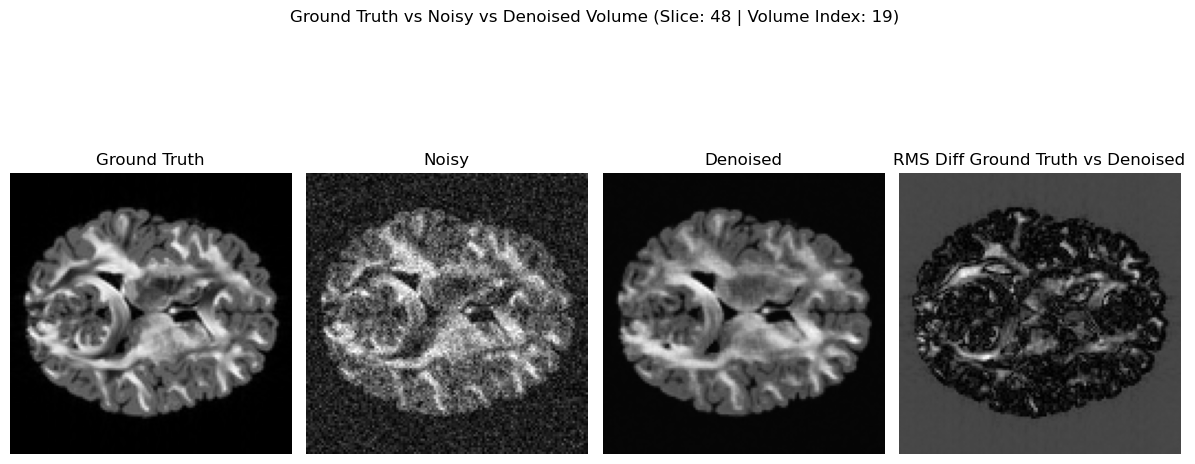

In [22]:
shape = (2, 3, 0, 1)

fully_compare_volumes(
    original_volume=np.transpose(ref_for_metrics, shape),
    noisy_volume=np.transpose(noisy_for_viz, shape),
    denoised_volume=np.transpose(reconstructed, shape),
    file_name=None,
    volume_idx=19,
)

In [30]:
reconstructed_2 = reconstruct_full_dwi_static_base(
    model=rec_model,
    noisy_xyzv=noisy_data[..., :15],
    train_num_volumes=train_num_volumes,
    device=rec_dev,
    mask_p=settings.reconstruct.mask_p,
    n_preds=50,  # settings.reconstruct.n_preds,
)

INFO:root:Starting DWI reconstruction on device: cuda
INFO:root:Input data shape: torch.Size([10, 128, 128, 96])
INFO:root:Using hybrid MD-S2S approach with mask_p=0.3, n_preds=50
INFO:root:Reconstruction completed. Output shape: (10, 128, 128, 96)
INFO:root:Output stats - Min: 0.0498, Max: 1.0518, Mean: 0.2061
INFO:root:static_base reconstruction: train_num_volumes=10, total_volumes=15
INFO:root:Starting DWI reconstruction on device: cuda
INFO:root:Input data shape: torch.Size([10, 128, 128, 96])
INFO:root:Using hybrid MD-S2S approach with mask_p=0.3, n_preds=50
INFO:root:Reconstruction completed. Output shape: (10, 128, 128, 96)
INFO:root:Output stats - Min: 0.0656, Max: 1.0481, Mean: 0.2065
INFO:root:Starting DWI reconstruction on device: cuda
INFO:root:Input data shape: torch.Size([10, 128, 128, 96])
INFO:root:Using hybrid MD-S2S approach with mask_p=0.3, n_preds=50
INFO:root:Reconstruction completed. Output shape: (10, 128, 128, 96)
INFO:root:Output stats - Min: 0.0598, Max: 1.063

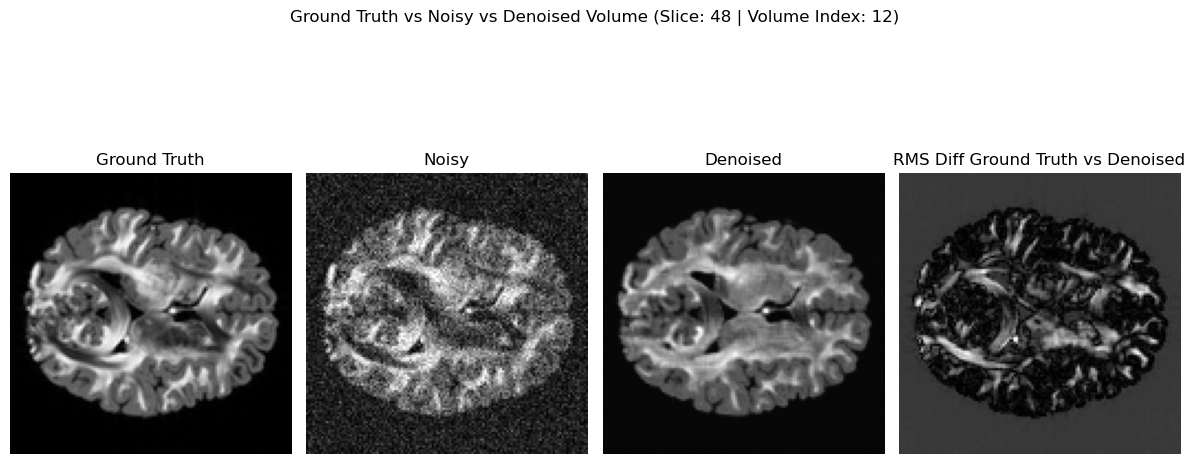

In [33]:
shape = (2, 3, 0, 1)

fully_compare_volumes(
    original_volume=np.transpose(ref_for_metrics, shape),
    noisy_volume=np.transpose(noisy_for_viz, shape),
    denoised_volume=np.transpose(reconstructed_2, shape),
    file_name=None,
    volume_idx=12,
)

# DRCNET
## output 1 volume at a time

In [1]:
import logging

# this ensures log messages go to the console and sets the minimum level to INFO
logging.basicConfig(level=logging.INFO)

# if you want to see debug messages, you can change it to:
# logging.basicConfig(level=logging.DEBUG)
# you can get a logger, often named after your module or just a general one
logger = logging.getLogger(__name__)

# now, use the logger to send messages at different levels
logger.debug("this is a debug message - you won't see it with INFO level config")
logger.info("this is an info message - you'll see this!")
logger.warning("this is a warning message - pay attention!")
logger.error("uh oh, an error occurred!")
logger.critical("system is failing!")

INFO:__main__:this is an info message - you'll see this!
ERROR:__main__:uh oh, an error occurred!
CRITICAL:__main__:system is failing!


In [2]:
from __future__ import annotations

import argparse
import gc
import logging
import os
import sys

import numpy as np
import torch
from drcnet_hybrid.data import TrainingDataSet
from drcnet_hybrid.fit import fit_model
from drcnet_hybrid.model import DenoiserNet
from drcnet_hybrid.reconstruction import (
    reconstruct_dwis,
    reconstruct_full_dwi_chunked,
    reconstruct_full_dwi_static_base,
    reconstruct_dwis_index_volume,
)
from drcnet_hybrid.run import fit_progressive
from torch.utils.data import DataLoader, Subset
from utils import setup_logging
from utils.checkpoint import load_checkpoint
from utils.data import (
    StanfordDataLoader,
    compute_brain_mask,
    rescale_reconstruction_to_01,
)
from utils.metrics import (
    compute_metrics,
    fully_compare_volumes,
    save_metrics,
    visualize_single_volume,
)
from utils.multi_gpu import create_multi_gpu_config_from_dict, setup_multi_gpu
from utils.utils import load_config, noise_path_segment

import wandb


def _build_checkpoint_dir(settings, train_num_volumes: int) -> str:
    noise_segment = noise_path_segment(
        getattr(settings.data, "noise_type", "rician"),
        getattr(settings.data, "noise_sigma", 0.1),
    )
    bvalue_segment = f"b{getattr(settings.data, 'bvalue', 2500)}"
    return os.path.join(
        settings.train.checkpoint_dir,
        bvalue_segment,
        f"num_volumes_{train_num_volumes}",
        noise_segment,
        f"learning_rate_{settings.train.learning_rate}",
    )


def _prepare_stanford_arrays(settings, train_num_volumes: int):
    d = settings.data
    data_loader = StanfordDataLoader(
        bvalue=d.bvalue,
        noise_sigma=d.noise_sigma,
    )
    original_data, noisy_data = data_loader.load_data()
    if original_data is None:
        original_data = noisy_data
        logging.info(
            "StanfordDataLoader returned original_data=None; using noisy_data as reference"
        )

    tx, ty, tz = d.take_x, d.take_y, d.take_z
    cropped_noisy = noisy_data[:tx, :ty, :tz, :].copy()
    cropped_orig = original_data[:tx, :ty, :tz, :].copy()

    n_b0 = int(d.num_b0s)
    dwi_noisy = cropped_noisy[..., n_b0:]
    dwi_orig = cropped_orig[..., n_b0:]
    n_dwi = dwi_noisy.shape[-1]
    logging.info(
        f"After spatial crop and b0 skip: DWI shape (X,Y,Z,V)={dwi_noisy.shape}, "
        f"V={n_dwi} diffusion volumes (excluding {n_b0} b0s)"
    )

    if train_num_volumes > n_dwi:
        raise ValueError(
            f"train_num_volumes={train_num_volumes} exceeds available DWI volumes ({n_dwi})"
        )

    train_noisy = dwi_noisy[..., :train_num_volumes]
    train_orig = dwi_orig[..., :train_num_volumes]

    return train_noisy, train_orig, dwi_noisy, dwi_orig


script_dir = "/home/paco/TechJourney/TechJourney/DWMRI/src/drcnet_hybrid/"
config_path = os.path.join(script_dir, "config.yaml")
settings = load_config(config_path).dbrain

train_num_volumes = int(getattr(settings.data, "train_num_volumes", settings.data.num_volumes))
reconstruct_full = bool(getattr(settings.data, "reconstruct_full_dwi", True))

settings.data.num_volumes = train_num_volumes
settings.model.in_channel = train_num_volumes

d = settings.data
spatial_full = (d.take_x, d.take_y, d.take_z)
rec_dev = settings.reconstruct.device

INFO:root:Loading configuration from: /home/paco/TechJourney/TechJourney/DWMRI/src/drcnet_hybrid/config.yaml
INFO:root:Configuration file loaded successfully
INFO:root:Configuration converted to Munch object


In [3]:
spatial_full

(128, 128, 96)

In [4]:
from utils.data import DBrainDataLoader

data_loader = DBrainDataLoader(
    nii_path=settings.data.nii_path,
    bvecs_path=settings.data.bvecs_path,
    bvalue=settings.data.bvalue,
    noise_sigma=settings.data.noise_sigma,
    noise_type=getattr(settings.data, "noise_type", "rician"),
    n_coils=getattr(settings.data, "noise_n_coils", 1),
)
original_data, noisy_data = data_loader.load_data()

INFO:root:DBrainDataLoader initialized - nii_path: /home/paco/d_brain/D_BRAIN_b2500_6_60_14_HCP_nless.nii, bvecs_path: /home/paco/d_brain/D_BRAIN_b2500_6_60_HCP_b_matrix.txt, bvalue: 2500, noise_sigma: 0.1, noise_type: rician, n_coils: 1
INFO:root:Loading data from /home/paco/d_brain/D_BRAIN_b2500_6_60_14_HCP_nless.nii
pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
INFO:nibabel.global:pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
INFO:root:Raw data loaded - shape: (128, 128, 97, 66), dtype: float64
INFO:root:Raw data stats - min: 0.0000, max: 7462.0000, mean: 159.3769
INFO:root:Normalizing spatial dimensions...
INFO:root:Normalizing spatial dimensions for data of shape (128, 128, 97, 66)
INFO:root:Spatial normalization completed - output shape: (128, 128, 97, 66)
INFO:root:Normalized data stats - min: 0.0000, max: 1.0000, mean: 0.1140
INFO:root:Adding rician noise with sigma=0.1 to data of shape (128, 128, 97, 66)
INFO:root:Noise added - noisy data sh

In [5]:
rec_model = DenoiserNet(
    input_channels=train_num_volumes,
    output_channels=settings.model.out_channel,
    groups=settings.model.groups,
    dense_convs=settings.model.dense_convs,
    residual=settings.model.residual,
    base_filters=settings.model.base_filters,
    output_shape=(
        settings.model.out_channel,
        spatial_full[0],
        spatial_full[1],
        spatial_full[2],
    ),
    device=settings.train.device,
    output_activation=getattr(settings.model, "output_activation", "prelu"),
)

INFO:root:Initializing DenoiserNet: input_channels=10, output_channels=1, groups=1, dense_convs=2, residual=True, base_filters=32, output_activation=prelu
INFO:root:Initializing GatedBlock: x_channels=32, h_channels=32, dense_convs=2, groups=1
INFO:root:Initializing DenoisingBlock: in_channels=64, inner_channels=32, out_channels=32, inner_convolutions=2, residual=False
INFO:root:Initializing FactorizedBlock: in_channels=96, out_channels=32, groups=1
INFO:root:Initializing FactorizedBlock: in_channels=128, out_channels=32, groups=1
INFO:root:DenoiserNet model created - Total parameters: 110,818, Trainable parameters: 110,818


In [6]:
checkpoint_dir = "/home/paco/TechJourney/TechJourney/DWMRI/src/drcnet_hybrid/checkpoints/dbrain/bvalue_2500/num_volumes_10/noise_rician_sigma_0.1/learning_rate_0.003/"
best_ckpt = os.path.join(checkpoint_dir, "best_loss_checkpoint.pth")

rec_model, _, _, _, _, _ = load_checkpoint(
    model=rec_model,
    optimizer=None,
    filename=best_ckpt,
    device=rec_dev,
    strict=False,
)

INFO:root:Attempting to load checkpoint from: /home/paco/TechJourney/TechJourney/DWMRI/src/drcnet_hybrid/checkpoints/dbrain/bvalue_2500/num_volumes_10/noise_rician_sigma_0.1/learning_rate_0.003/best_loss_checkpoint.pth
INFO:root:Checkpoint loaded successfully: /home/paco/TechJourney/TechJourney/DWMRI/src/drcnet_hybrid/checkpoints/dbrain/bvalue_2500/num_volumes_10/noise_rician_sigma_0.1/learning_rate_0.003/best_loss_checkpoint.pth
INFO:root:Checkpoint details - epoch: 13, loss: 0.007566, best_loss: 0.007566
INFO:root:Scheduler state found in checkpoint


In [7]:
take_volumes = settings.data.num_b0s + settings.data.num_volumes
noisy_data = noisy_data[
    : settings.data.take_x,
    : settings.data.take_y,
    : settings.data.take_z,
    settings.data.num_b0s :,
]
original_data = original_data[
    : settings.data.take_x,
    : settings.data.take_y,
    : settings.data.take_z,
    settings.data.num_b0s :,
]

In [8]:
noisy_data.shape

(128, 128, 96, 60)

In [9]:
reconstructed = reconstruct_full_dwi_chunked(
    model=rec_model,
    noisy_xyzv=noisy_data[..., :15],
    train_num_volumes=train_num_volumes,
    device=rec_dev,
    mask_p=settings.reconstruct.mask_p,
    n_preds=100,  # settings.reconstruct.n_preds,
)

INFO:root:Chunked reconstruction: padded last dim by 5 (edge) so V is multiple of 10
INFO:root:Starting DWI reconstruction on device: cuda:0
INFO:root:Input data shape: torch.Size([10, 128, 128, 96])
INFO:root:Using hybrid MD-S2S approach with mask_p=0.3, n_preds=100
Processing volumes: 100%|██████████| 10/10 [01:45<00:00, 10.58s/it]
INFO:root:Reconstruction completed. Output shape: (10, 128, 128, 96)
INFO:root:Output stats - Min: 0.0223, Max: 1.0321, Mean: 0.2086
INFO:root:Starting DWI reconstruction on device: cuda:0
INFO:root:Input data shape: torch.Size([10, 128, 128, 96])
INFO:root:Using hybrid MD-S2S approach with mask_p=0.3, n_preds=100
Processing volumes: 100%|██████████| 10/10 [01:45<00:00, 10.51s/it]
INFO:root:Reconstruction completed. Output shape: (10, 128, 128, 96)
INFO:root:Output stats - Min: 0.0226, Max: 1.1275, Mean: 0.2121


In [10]:
ref_for_metrics = original_data
noisy_for_viz = noisy_data
# reconstructed = reconstructed

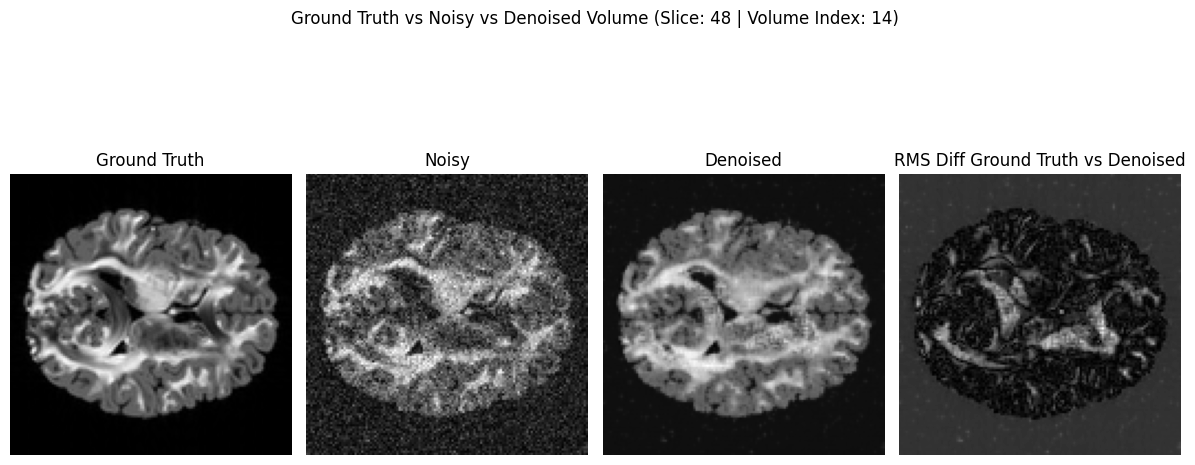

In [19]:
shape = (2, 3, 0, 1)

fully_compare_volumes(
    original_volume=np.transpose(ref_for_metrics, shape),
    noisy_volume=np.transpose(noisy_for_viz, shape),
    denoised_volume=np.transpose(reconstructed, shape),
    file_name=None,
    volume_idx=14,
)

In [11]:
reconstructed_2 = reconstruct_full_dwi_static_base(
    model=rec_model,
    noisy_xyzv=noisy_data[..., :15],
    train_num_volumes=train_num_volumes,
    device=rec_dev,
    mask_p=settings.reconstruct.mask_p,
    n_preds=50,  # settings.reconstruct.n_preds,
)

INFO:root:Starting DWI reconstruction on device: cuda:0
INFO:root:Input data shape: torch.Size([10, 128, 128, 96])
INFO:root:Using hybrid MD-S2S approach with mask_p=0.3, n_preds=50
Processing volumes: 100%|██████████| 10/10 [00:52<00:00,  5.30s/it]
INFO:root:Reconstruction completed. Output shape: (10, 128, 128, 96)
INFO:root:Output stats - Min: 0.0219, Max: 1.0312, Mean: 0.2086
INFO:root:Starting DWI reconstruction on device: cuda:0
INFO:root:Input data shape: torch.Size([10, 128, 128, 96])
INFO:root:Using hybrid MD-S2S approach with mask_p=0.3, n_preds=50
Processing volumes: 100%|██████████| 1/1 [00:05<00:00,  5.24s/it]
INFO:root:Reconstruction completed. Output shape: (10, 128, 128, 96)
INFO:root:Output stats - Min: 0.0000, Max: 0.9269, Mean: 0.0211
INFO:root:Starting DWI reconstruction on device: cuda:0
INFO:root:Input data shape: torch.Size([10, 128, 128, 96])
INFO:root:Using hybrid MD-S2S approach with mask_p=0.3, n_preds=50
Processing volumes: 100%|██████████| 1/1 [00:05<00:00,

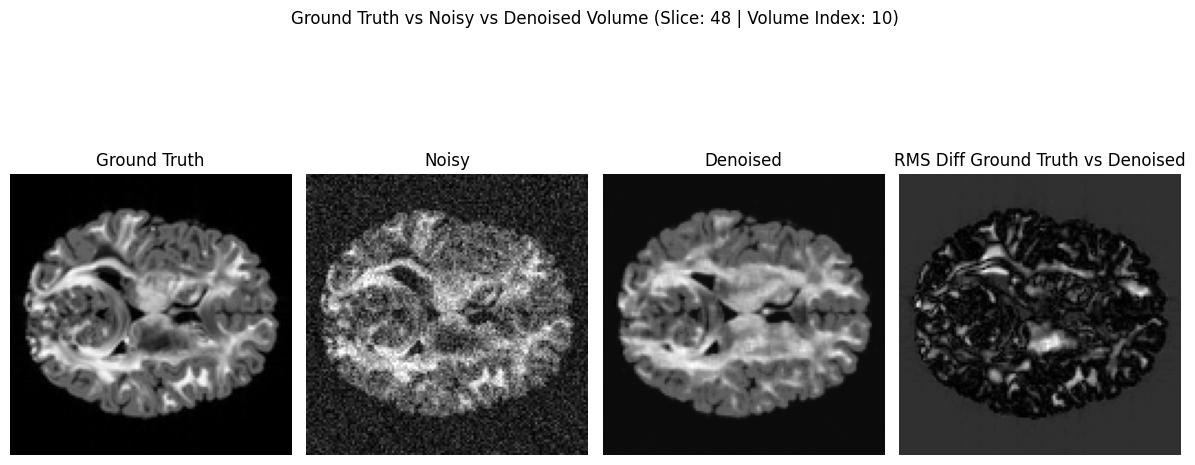

In [18]:
shape = (2, 3, 0, 1)

fully_compare_volumes(
    original_volume=np.transpose(ref_for_metrics, shape),
    noisy_volume=np.transpose(noisy_for_viz, shape),
    denoised_volume=np.transpose(reconstructed_2, shape),
    file_name=None,
    volume_idx=10,
)

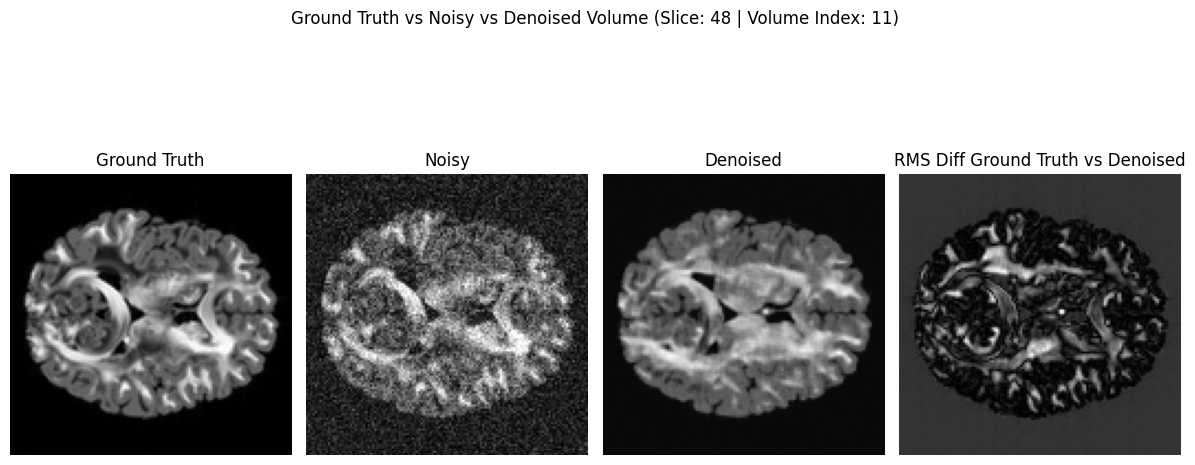

In [19]:
shape = (2, 3, 0, 1)

fully_compare_volumes(
    original_volume=np.transpose(ref_for_metrics, shape),
    noisy_volume=np.transpose(noisy_for_viz, shape),
    denoised_volume=np.transpose(reconstructed_2, shape),
    file_name=None,
    volume_idx=11,
)